# Energy budgets

Compute a time series for the energy components (horizontal and vertical kinetic, internal, potential and latent) and exchanges (horizontal kinetic to potential and internal, and vice versa). This can be done as either a single scalar at each time level, or as a 1D vertical column or 2D horizontal slice, and as an integral over time for the exchanges. These diagnostics can be used to provide insights into how energy evolves between components, and as a total budget within a global or a regional domain

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from scores.dynamics import energy_components_lat_lon, energy_exchanges_lat_lon
import matplotlib.pyplot as plt

In [2]:
START_TIME = pd.Timestamp("2020-01-01")
END_TIME = pd.Timestamp("2020-02-01")
ds = xr.open_zarr("gs://weatherbench2/datasets/era5/1959-2023_01_10-6h-240x121_equiangular_with_poles_conservative.zarr")
ds = ds.sel(time=slice(START_TIME, END_TIME))

Prepare the fields for the energy budget time series, using the zonal, meridional and vertical velocities, the temperature, water vapor, surface pressure and surface geopotential (the orography).

In [3]:
fieldnames = ['u_component_of_wind','v_component_of_wind','vertical_velocity','temperature','specific_humidity','geopotential','surface_pressure','geopotential_at_surface']
ds = ds[fieldnames]
ds = ds.compute()
ds = ds.rename({'u_component_of_wind': 'u', 'v_component_of_wind': 'v', 'vertical_velocity': 'w', 'temperature': 't', 'specific_humidity': 'q', 'geopotential': 'z', 'surface_pressure': 'sp', 'geopotential_at_surface': 'zs'})

Specify a sub-domain of the global to compute the budgets over

In [4]:
sub_domain_latitude = ds.latitude[(ds.latitude >= -60) & (ds.latitude <= -20)]
sub_ds = ds.sel(latitude=sub_domain_latitude)

Compute a time series for the internal, latent, potential and horizontal and vertical kinetic energies:

Internal = $\int_{p_1}^{p_0}\int_{\Omega}(C_p^d(1-q) + C_p^vq)T\mathrm{d}\Omega\mathrm{d}p$ 

Latent = $\int_{p_1}^{p_0}\int_{\Omega}L_vq\mathrm{d}\Omega\mathrm{d}p$ 

Potential = $\int_{\Omega}z_s\Phi_s\mathrm{d}\Omega$ 

Kinetic (horizontal) = $\int_{p_1}^{p_0}\int_{\Omega}\frac{1}{2}(u^2 + v^2)\mathrm{d}\Omega\mathrm{d}p$ 

Kinetic (vertical) = $\int_{p_1}^{p_0}\int_{\Omega}\frac{1}{2}w^2\mathrm{d}\Omega\mathrm{d}p$

where: $p_1$ and $p_0$ are the bottom and top level pressures ($Pa$), $C_p^d$ and $C_p^v$ are the specific heads of dry air and vapor at constant pressure ($J/kg/K$), $L_v$ is the latent heat of vaporisation ($J/kg$), $T$ is the temperature ($K$), $q$ is the mass fraction of moist air ($kg/kg$), $z_s$ is the surface geopotential ($m^2/s^2$), $\Phi_s$ is the surface pressure ($Pa$), and $u$, $v$, $w$ are the zonal, meridional and vertical velocities ($m/s$).

References: 
- Trenberth, K. E., Stepaniak, D. P., Caron, J. M. (2002) "Accuracy of Atmospheric Energy Budgets from Analyses" J. Clim. 15 3343--3360
- Sha, Y., Schreck, J. S., Chapman, W., Gagne, D. J. (2025) "Improving AI Weather Prediction Models using Global Mass and Energy Conservation Schemes" arXiv:2501.05648v2
- Taylor, M. A. (2011). Conservation of mass and energy for the moist atmospheric primitive equations on unstructured grids. In P. H.
Lauritzen, et al. (Eds.), Numerical techniques for global atmospheric models, Lecture Notes Comput. Sci. Eng. (Vol. 80, pp. 357–380).
Heidelberg, Germany: Springer.

In [5]:
E = energy_components_lat_lon(sub_ds)

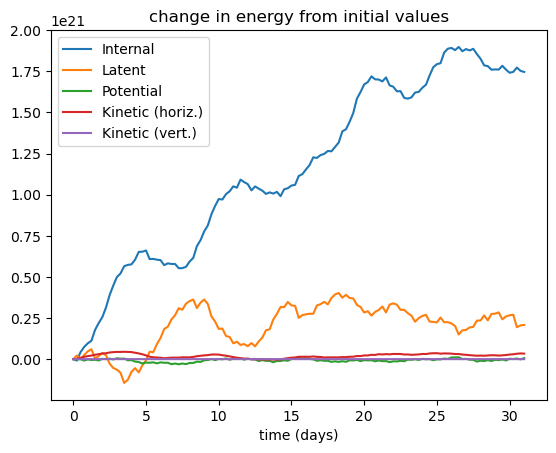

In [6]:
time=0.25*np.arange(len(E.time))
e_names = ['Internal','Latent','Potential','Kinetic (horiz.)','Kinetic (vert.)']
plt.plot(time,E["Internal"].data-E["Internal"].data[0])
plt.plot(time,E["Latent"].data-E["Latent"].data[0])
plt.plot(time,E["Potential"].data-E["Potential"].data[0])
plt.plot(time,E["HorizontalKinetic"].data-E["HorizontalKinetic"].data[0])
plt.plot(time,E["VerticalKinetic"].data-E["VerticalKinetic"].data[0])
plt.legend(e_names)
plt.title('change in energy from initial values')
plt.xlabel('time (days)')
plt.show()

The growth in internal and latent energies represent a drift in the temperature and total water mass within the domain over time. Note that the absolute values of internal and latent energy are large in comparison to the kientic energies (horizontal and vertical). These changes could be attributable to either fluxes entering the domain, external sources (ie: solar radiation) or model bias.

Compute a time series for the kinetic to internal, internal to kinetic, kinetic to potential and potential to kinetic energy exchanges as:

Kinetic to Internal = $\int_{p_1}^{p_0}\int_{\Omega}\nabla(z-z_s)\cdot\boldsymbol{u}\mathrm{d}\Omega\mathrm{d}p$

Internal to Kinetic = $\int_{p_1}^{p_0}\int_{\Omega}(z-z_s)\nabla\cdot\boldsymbol{u}\mathrm{d}\Omega\mathrm{d}p$

Kinetic to Potential = $\int_{p_1}^{p_0}\int_{\Omega}\nabla z_s\cdot\boldsymbol{u}\mathrm{d}\Omega\mathrm{d}p$

Potential to Kinetic = $\int_{p_1}^{p_0}\int_{\Omega}z_s\nabla\cdot\boldsymbol{u}\mathrm{d}\Omega\mathrm{d}p$

In [7]:
Ex = energy_exchanges_lat_lon(sub_ds)

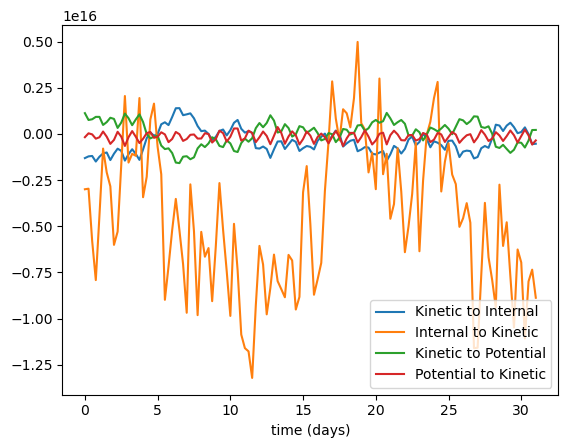

In [8]:
time=0.25*np.arange(len(Ex.time))
ex_names = ['Kinetic to Internal','Internal to Kinetic','Kinetic to Potential','Potential to Kinetic']
plt.plot(time,Ex["KineticToInternal"].data)
plt.plot(time,Ex["InternalToKinetic"].data)
plt.plot(time,Ex["KineticToPotential"].data)
plt.plot(time,Ex["PotentialToKinetic"].data)
plt.legend(ex_names)
plt.xlabel('time (days)')
plt.show()

For a periodic domain (like the full earth), the kinetic to internal exchanges should exactly balance the internal to kinetic exchanges (as for the kinetic to potential and potential to kinetic exchanges). However in a domain with open boundaries there will be fluxes that break this balance. For the southern hemisphere domain presented here there are significant differents in the internal to kinetic energy exchange, suggesting large temperature fluxes into the domain. 

Now lets compute a 1D global vertical profile of the energy components at each time level by preserving the vertical "level" dimension:

In [9]:
E = energy_components_lat_lon(ds, preserve_vertical=True)

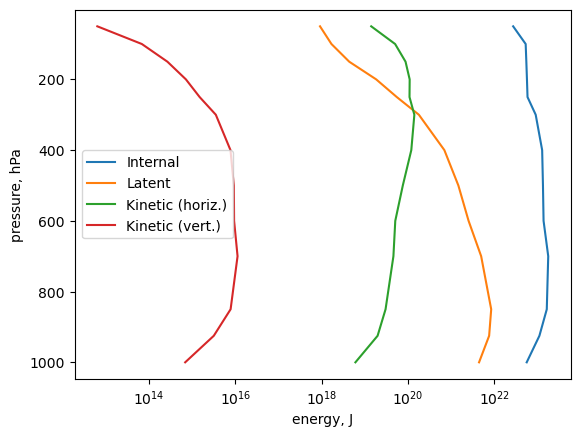

In [10]:
plt.semilogx(E["Internal"].sel(time=E.time[-1]),E.level)
plt.semilogx(E["Latent"].sel(time=E.time[-1]),E.level)
plt.semilogx(E["HorizontalKinetic"].sel(time=E.time[-1]),E.level)
plt.semilogx(E["VerticalKinetic"].sel(time=E.time[-1]),E.level)
plt.gca().invert_yaxis()
plt.legend(['Internal','Latent','Kinetic (horiz.)','Kinetic (vert.)'])
plt.xlabel('energy, J')
plt.ylabel('pressure, hPa')
plt.show()

Note that at each vertical pressure level the energy is integrated across the width of the pressure level, which are not evenly spaced.

Conversely, we can also intergrate in the vertical only, in order to genreate a 2D horizontal plot of the different energy components at each time level:

In [11]:
E = energy_components_lat_lon(ds, preserve_horizontal=True)

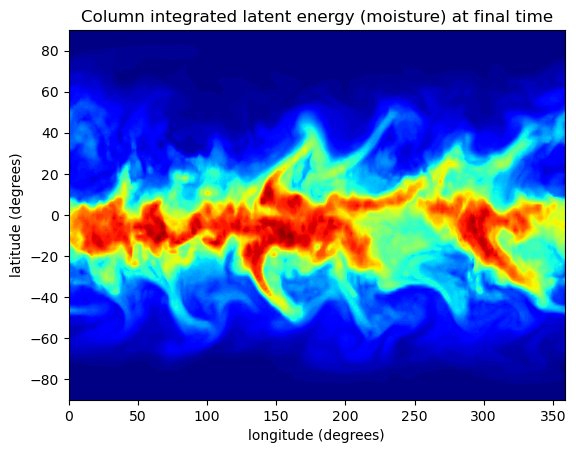

In [12]:
plt.rcParams['image.cmap'] = 'jet'
lat2d,lon2d=np.meshgrid(E.latitude.data,E.longitude.data)
plt.contourf(lon2d,lat2d,E["Latent"].sel(time=E.time[-1]).data,100)
plt.title('Column integrated latent energy (moisture) at final time')
plt.xlabel('longitude (degrees)')
plt.ylabel('latitude (degrees)')
plt.show()

We can also generate vertical profiles of the energy exchanges, integrated over the horizontal and over time:

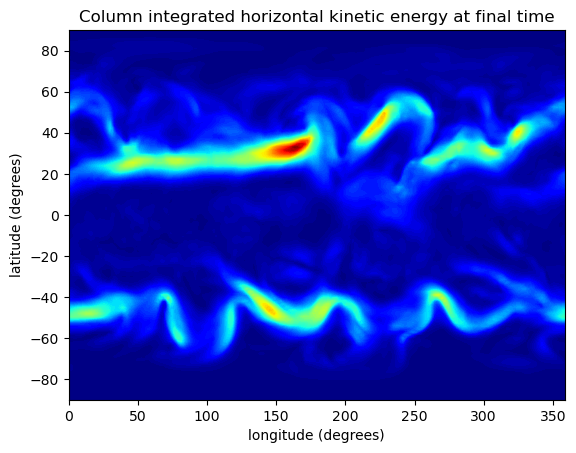

In [13]:
plt.title('Column integrated horizontal kinetic energy at final time')
plt.contourf(lon2d,lat2d,E["HorizontalKinetic"].sel(time=E.time[-1]).data,100)
plt.xlabel('longitude (degrees)')
plt.ylabel('latitude (degrees)')
plt.show()

The mid latitude jets and meanders are clearly visible in the vertically integrated kinetic energy

We can also generate vertical profiles of the energy exchanges, integrated over the horizontal and over time:

In [14]:
Ex = energy_exchanges_lat_lon(ds, reduce_time=True, preserve_vertical=True)

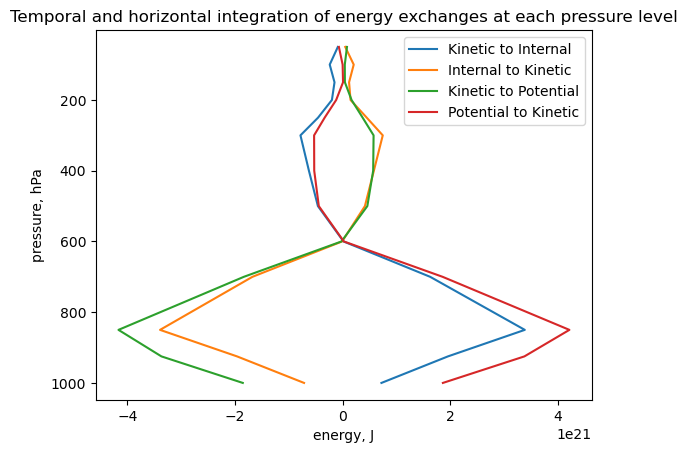

In [15]:
plt.plot(Ex["KineticToInternal"],Ex.level)
plt.plot(Ex["InternalToKinetic"],Ex.level)
plt.plot(Ex["KineticToPotential"],Ex.level)
plt.plot(Ex["PotentialToKinetic"],Ex.level)
plt.gca().invert_yaxis()
plt.title('Temporal and horizontal integration of energy exchanges at each pressure level')
plt.legend(['Kinetic to Internal','Internal to Kinetic','Kinetic to Potential','Potential to Kinetic'])
plt.xlabel('energy, J')
plt.ylabel('pressure, hPa')
plt.show()

The approximate balance at each pressure level is clearly visible when then energy exchanges are ingtegrated globally in the horizontal and in time.

In [16]:
Ex = energy_exchanges_lat_lon(ds, reduce_time=True, preserve_horizontal=True)

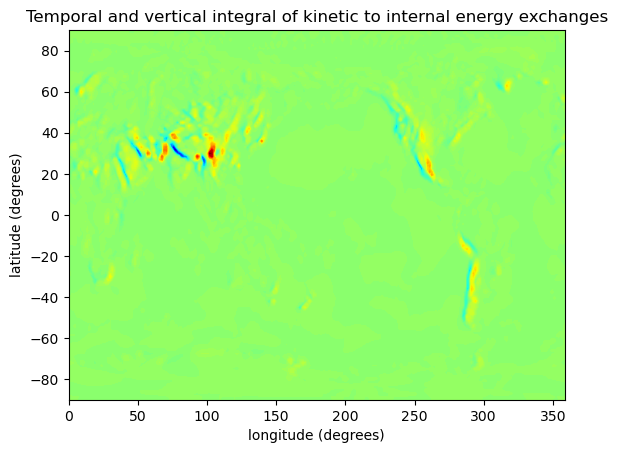

In [17]:
plt.rcParams['image.cmap'] = 'jet'
lat2d,lon2d=np.meshgrid(Ex.latitude.data,Ex.longitude.data)
plt.contourf(lon2d,lat2d,Ex["KineticToInternal"].data,100)
plt.title('Temporal and vertical integral of kinetic to internal energy exchanges')
plt.xlabel('longitude (degrees)')
plt.ylabel('latitude (degrees)')
plt.show()

The strongest vertically and temporally integrated kinetic to internal energy exchanges are observed over orography, presumably due to the generation of orographic gravity waves.